# Lab 13

## Section 1: PyTorch



## Import Torch

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim

In [35]:
pip install torch

### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [37]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: cuda


torch.Tensor

In [38]:
sample_input

tensor([[ 1.4613, -0.1795,  0.2622, -0.8512,  0.0629, -1.2336, -0.2062, -1.0174,
          0.2759, -1.2685]], device='cuda:0')

## Section 2: MNIST Project
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [39]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [40]:
training_data = datasets.FASION_MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

AttributeError: module 'torchvision.datasets' has no attribute 'FASION_MNIST'

In [ ]:
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Visualizing One Image & Understanding Shapes

In [ ]:
len(training_data)

60000

In [ ]:
len(test_data)

10000

In [ ]:
img, label = training_data[0]

In [ ]:
img.shape

torch.Size([1, 28, 28])

In [ ]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [ ]:
img.squeeze().shape

torch.Size([28, 28])

## Display one Image in MatplotLib

In [ ]:
import matplotlib.pyplot as plt

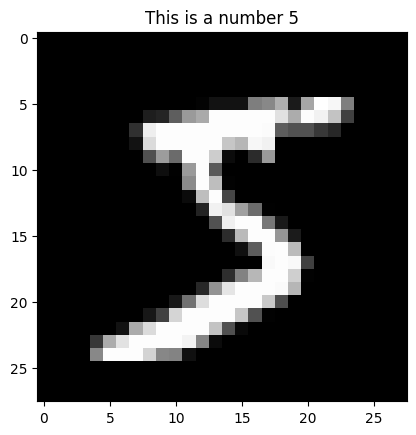

In [ ]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"This is a number {label}")
plt.show()

# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [ ]:
img, label = training_data[1]

In [ ]:

img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

In [ ]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        self.layers = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),# Activation
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model = SimpleNet()
print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [ ]:
from torch.utils.data import DataLoader

# Create stacks
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
def train():
    model.train()

    # Epoch Loop - Train for multiple epochs
    num_epochs = 5

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")

        for batch_No, (data, target) in enumerate(train_loader):

            output = model(data)

            loss = loss_fn(output, target)

            # Backpropagation
            optimizer.zero_grad()  # Clear old calculations
            loss.backward()        # Calculate gradients
            optimizer.step()       # Update weights

            if batch_No % 100 == 0:
                print(f"Batch {batch_No}: Loss = {loss.item():.4f}")

        print(f"Epoch {epoch + 1} completed!")

# Run training

In [ ]:
train()


--- Epoch 1/5 ---
Batch 0: Loss = 2.3164
Batch 100: Loss = 0.4511
Batch 200: Loss = 0.6044
Batch 300: Loss = 0.2869
Batch 400: Loss = 0.3043
Batch 500: Loss = 0.2833
Batch 600: Loss = 0.3493
Batch 700: Loss = 0.2506
Batch 800: Loss = 0.2322
Batch 900: Loss = 0.2810
Epoch 1 completed!

--- Epoch 2/5 ---
Batch 0: Loss = 0.1932
Batch 100: Loss = 0.1300
Batch 200: Loss = 0.1943
Batch 300: Loss = 0.3003
Batch 400: Loss = 0.1004
Batch 500: Loss = 0.0818
Batch 600: Loss = 0.2628
Batch 700: Loss = 0.0682
Batch 800: Loss = 0.2873
Batch 900: Loss = 0.1254
Epoch 2 completed!

--- Epoch 3/5 ---
Batch 0: Loss = 0.2311
Batch 100: Loss = 0.0977
Batch 200: Loss = 0.1086
Batch 300: Loss = 0.0882
Batch 400: Loss = 0.0871
Batch 500: Loss = 0.0602
Batch 600: Loss = 0.0477
Batch 700: Loss = 0.0953
Batch 800: Loss = 0.0562
Batch 900: Loss = 0.1981
Epoch 3 completed!

--- Epoch 4/5 ---
Batch 0: Loss = 0.1429
Batch 100: Loss = 0.1827
Batch 200: Loss = 0.1459
Batch 300: Loss = 0.0486
Batch 400: Loss = 0.1149


In [ ]:
for name, param in model.named_parameters():
    print(f"{name} : {param.shape}")

layers.0.weight : torch.Size([128, 784])
layers.0.bias : torch.Size([128])
layers.2.weight : torch.Size([10, 128])
layers.2.bias : torch.Size([10])


In [ ]:
def test():
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)

            prediction = output.argmax(dim=1)

            correct += (prediction == target).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.1%}")

test()

Test Accuracy: 97.2%


In [ ]:
def predict_img(index):
  model.eval()

  img, actual_label=test_data[index]

  input_tensor=img.unsqueeze(0)

  with torch.no_grad():
    logits=model(input_tensor)
    predict_label=logits.argmax(dim=1)

  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(f"Actual {actual_label} | Predicted {predict_label}")
  plt.show()

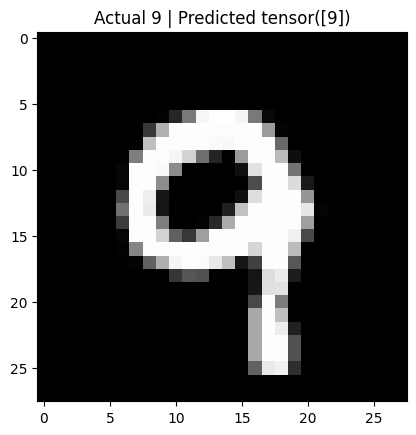

In [ ]:
predict_img(99)